# Thompson Sampling

## Importing the libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Importing the dataset

In [2]:
dataset = pd.read_csv('Ads_CTR_Optimisation.csv')

## Implementing Thompson Sampling

In [3]:
import random

In [14]:
N = 300
d = 10
ads_selected = []

numbers_ofrewards_1 = [0]*d
numbers_of_rewards_0 = [0]*d
total_reward = 0

In [15]:
for n in range(0,N):
    ad = 0
    max_random = 0
    for i in range(0,d):
        alpha = numbers_ofrewards_1[i] + 1
        beta = numbers_of_rewards_0[i] + 1

        random_number = random.betavariate(alpha,beta)

        if random_number>max_random :
            max_random = random_number
            ad = i
    
    ads_selected.append(ad)
    
    if dataset.values[n,ad] == 1:
        numbers_ofrewards_1[ad]+= 1
        total_reward +=1
    else:
        numbers_of_rewards_0[ad]+=1
        total_reward += 0

## Visualising the results of Thompson Sampling

Text(0, 0.5, 'Number of times each ad was selected')

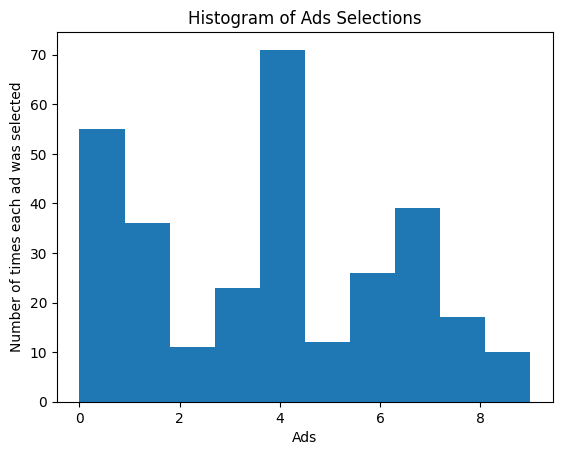

In [16]:
plt.hist(ads_selected)
plt.title('Histogram of Ads Selections')
plt.xlabel('Ads')
plt.ylabel('Number of times each ad was selected')

# Upper Confidence Bound

In [37]:
N = 600
d = 10

ads_selected = []

total_sum_rewards = [0]*d
ad_selections = [0]*d

total_reward = 0

In [38]:
for n in range(0,N):
    max_ucb = 0
    ad = 0
    for i in range(0,d):

        if ad_selections[i] > 0 :
            empirical_mean = total_sum_rewards[i] / ad_selections[i]

            ucb = empirical_mean + np.sqrt(3/2 * (np.log(n+1) / ad_selections[i]))

        else:
            ucb = 1e400
        

        if ucb>max_ucb :
            max_ucb = ucb
            ad = i
    
    ads_selected.append(ad)
    reward = dataset.values[n,ad]
    total_sum_rewards[ad]+= reward
    ad_selections[ad] +=1

# Visualizing the rewards of Upper Confidence Bound Algorithm

Text(0, 0.5, 'Number of times each ad was selected')

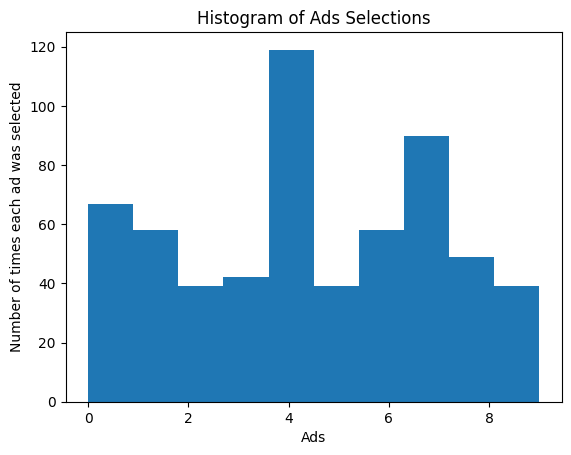

In [39]:
plt.hist(ads_selected)
plt.title('Histogram of Ads Selections')
plt.xlabel('Ads')
plt.ylabel('Number of times each ad was selected')

# Comparison between Thompson Sampling and UCB (Upper Confidence Bound)

Thompson sampling is a a more powerful algorithm . It identifies the best ad (which is 4) in 300 rounds smaller than UCB which identifies it in 600 rounds . 
NOTE : UCB is not able to identify ad 4 as the best ad below 500 rounds